In [1]:
#importing necessary libraries
!pip install prophet scikit-learn statsmodels tensorflow keras-tuner openpyxl matplotlib seaborn -q

In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import product

# Statistical
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Metrics & preprocessing
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
np.random.seed(42)

# LSTM / Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt


In [3]:
#Data loading and preparation
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
file_path = '/content/drive/MyDrive/FYP - Dataset/Sugar Confectionery.xlsx'

df_raw = pd.read_excel(file_path, header=5)

df_raw.columns = df_raw.columns.str.strip()

print('Raw shape:', df_raw.shape)
print('Levels in dataset:', df_raw['LEVEL'].unique())

Raw shape: (14852, 46)
Levels in dataset: ['CATEGORY' 'SUB CATEGORY' 'SSUB CATEGORY' 'COMPANY' 'MBRAND' 'BRAND'
 'SKU']


In [5]:
#Filtering
TARGET_COMPANY = 'SUNSHINE CONSUMER LANKA LTD'

df = df_raw[
    (df_raw['COMPANY'] == TARGET_COMPANY) &
    (df_raw['LEVEL'] == 'COMPANY')
].copy()

print(f'Rows for {TARGET_COMPANY} at COMPANY level: {len(df)}')
print('Sub-categories found:', df['SUB CATEGORY'].unique())

Rows for SUNSHINE CONSUMER LANKA LTD at COMPANY level: 111
Sub-categories found: ['BUBBLE GUM/CHEWING GUM' 'HARD BOILED CANDIES' 'JELLY DROPS & JELLY'
 'JUJUBES' 'LOLLIPOPS' 'MINT/COUGH LOZENGES' 'TOFFEES']


In [6]:
MONTHS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

month_cols = [
    c for c in df.columns
    if any(c.upper().startswith(m + ' ') for m in MONTHS)
]

print(f'Month columns detected ({len(month_cols)}):', month_cols)

Month columns detected (36): ['JAN 23', 'FEB 23', 'MAR 23', 'APR 23', 'MAY 23', 'JUN 23', 'JUL 23', 'AUG 23', 'SEP 23', 'OCT 23', 'NOV 23', 'DEC 23', 'JAN 24', 'FEB 24', 'MAR 24', 'APR 24', 'MAY 24', 'JUN 24', 'JUL 24', 'AUG 24', 'SEP 24', 'OCT 24', 'NOV 24', 'DEC 24', 'JAN 25', 'FEB 25', 'MAR 25', 'APR 25', 'MAY 25', 'JUN 25', 'JUL 25', 'AUG 25', 'SEP 25', 'OCT 25', 'NOV 25', 'DEC 25']


In [7]:
#Melt to long format
id_cols = ['MARKET', 'SUB CATEGORY']
df_long = df.melt(
    id_vars=id_cols,
    value_vars=month_cols,
    var_name='Month',
    value_name='Sales_Volume'
).rename(columns={'SUB CATEGORY': 'Candy_Type', 'MARKET': 'Region'})

In [8]:
#Converting month strings
df_long['Month'] = pd.to_datetime(df_long['Month'], format='%b %y')

#Replacing '-' placeholders with NaN before numeric conversion
df_long['Sales_Volume'] = df_long['Sales_Volume'].replace('-', np.nan)
df_long['Sales_Volume'] = pd.to_numeric(df_long['Sales_Volume'], errors='coerce')


In [9]:
#Dropping rows with no sales data
df_long = df_long.dropna(subset=['Sales_Volume'])
df_long = df_long[df_long['Sales_Volume'] > 0]

print('shape:', df_long.shape)

shape: (3634, 4)


In [10]:
#Keeping only geographic regions
VALID_REGIONS = [
    'ALL ISLAND', 'Central', 'Eastern', 'Northern',
    'North Central', 'North Western', 'Southern',
    'Western', 'Sabaragamuwa', 'Uva','RURAL',
    'URBAN'
]

#Excluding JELLY DROPS (very sparse data)
EXCLUDE_CATEGORIES = ['JELLY DROPS & JELLY']

df_clean = df_long[
    df_long['Region'].isin(VALID_REGIONS) &
    ~df_long['Candy_Type'].isin(EXCLUDE_CATEGORIES)
].copy()

In [11]:
#Aggregating across category
df_clean = df_clean.groupby(
    ['Month', 'Region', 'Candy_Type'], as_index=False
)['Sales_Volume'].sum()

df_clean = df_clean.sort_values(['Candy_Type', 'Region', 'Month']).reset_index(drop=True)

print('Final clean shape:', df_clean.shape)
print('Date range:', df_clean['Month'].min(), '→', df_clean['Month'].max())
print('Regions:', df_clean['Region'].nunique())
print('Candy types:', df_clean['Candy_Type'].nunique())
df_clean.head()

Final clean shape: (2506, 4)
Date range: 2023-01-01 00:00:00 → 2025-12-01 00:00:00
Regions: 12
Candy types: 6


,Month,Region,Candy_Type,Sales_Volume
0,2023-01-01,ALL ISLAND,BUBBLE GUM/CHEWING GUM,3.019625
1,2023-02-01,ALL ISLAND,BUBBLE GUM/CHEWING GUM,2.856832
2,2023-03-01,ALL ISLAND,BUBBLE GUM/CHEWING GUM,3.251534
3,2023-04-01,ALL ISLAND,BUBBLE GUM/CHEWING GUM,2.447465
4,2023-05-01,ALL ISLAND,BUBBLE GUM/CHEWING GUM,1.677451


In [12]:
#Checking coverage
coverage = df_clean.groupby(['Region', 'Candy_Type'])['Month'].count().reset_index()
coverage.columns = ['Region', 'Candy_Type', 'Months_Available']
print(coverage.pivot(index='Region', columns='Candy_Type', values='Months_Available').fillna(0).astype(int))

Candy_Type     BUBBLE GUM/CHEWING GUM  HARD BOILED CANDIES  JUJUBES  \
Region                                                                
ALL ISLAND                         36                   36       36   
Central                            36                   36       28   
Eastern                            36                   36       29   
North Central                      36                   36       25   
North Western                      36                   36       28   
Northern                           36                   36       17   
RURAL                              36                   36       36   
Sabaragamuwa                       36                   36       35   
Southern                           36                   36       35   
URBAN                              36                   36       36   
Uva                                36                   36       13   
Western                            36                   36       36   

Candy

In [13]:
#Saving clean data file
df_clean.to_csv('clean_data.csv', index=False)

In [14]:
#Exploratary Data Analysis (EDA)
df_clean.isnull().sum()
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2506 entries, 0 to 2505
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Month         2506 non-null   datetime64[ns]
 1   Region        2506 non-null   object        
 2   Candy_Type    2506 non-null   object        
 3   Sales_Volume  2506 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 78.4+ KB


,Month,Sales_Volume
count,2506,2506.000000
mean,2024-06-16 19:53:29.257781248,1.104493
min,2023-01-01 00:00:00,0.000036
25%,2023-10-01 00:00:00,0.063761
50%,2024-07-01 00:00:00,0.189145
75%,2025-04-01 00:00:00,0.782004
max,2025-12-01 00:00:00,23.170368
std,NaN,3.042066


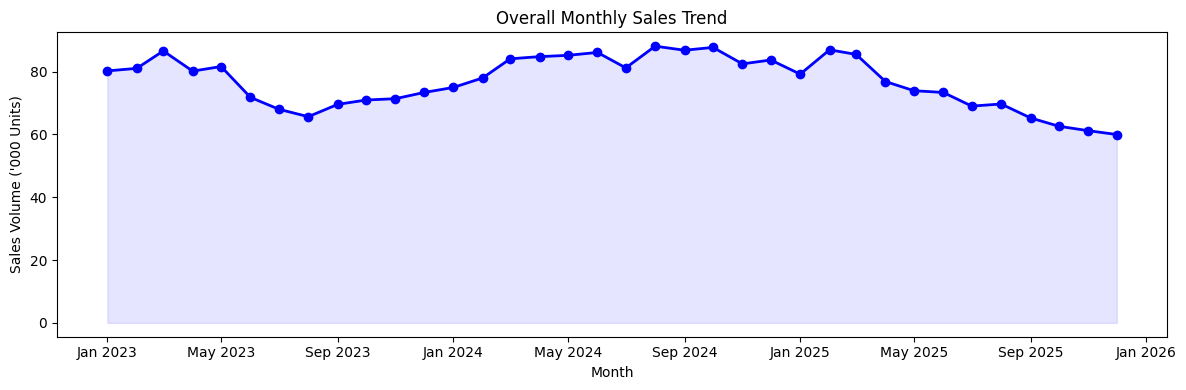

In [15]:
#Plotting
#Overall monthly trend
total_trend = df_clean.groupby('Month')['Sales_Volume'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(total_trend.index, total_trend.values, marker='o', linewidth=2, color='blue')
ax.fill_between(total_trend.index, total_trend.values, alpha=0.1, color='blue')
ax.set_title('Overall Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel("Sales Volume ('000 Units)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

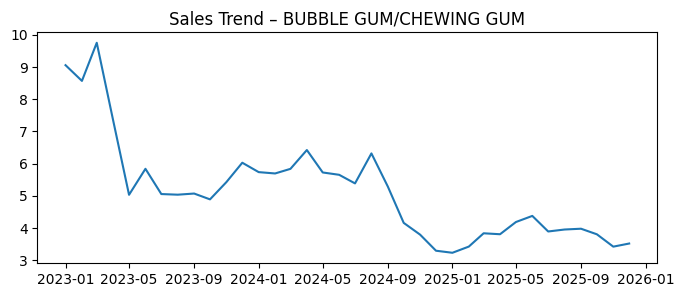

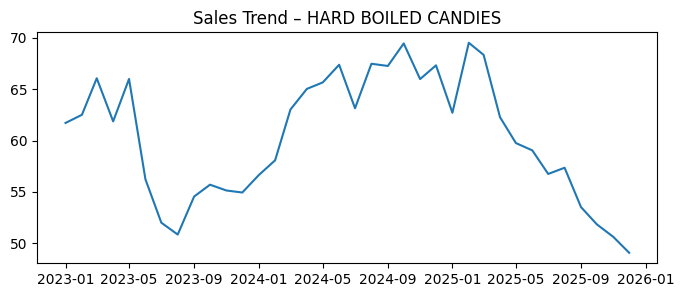

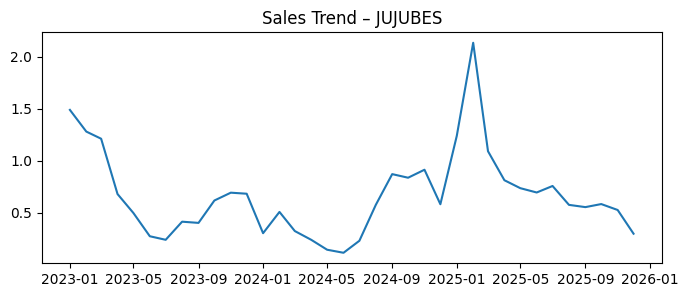

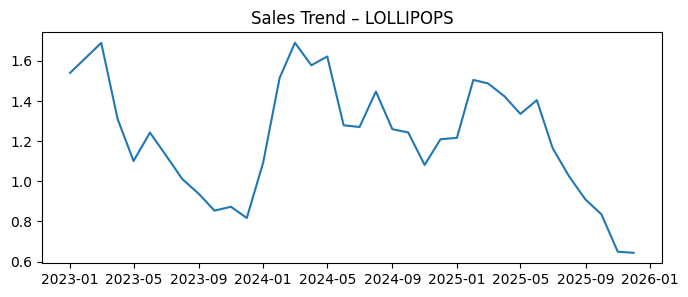

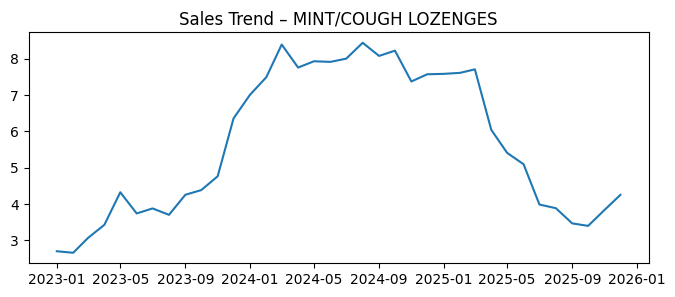

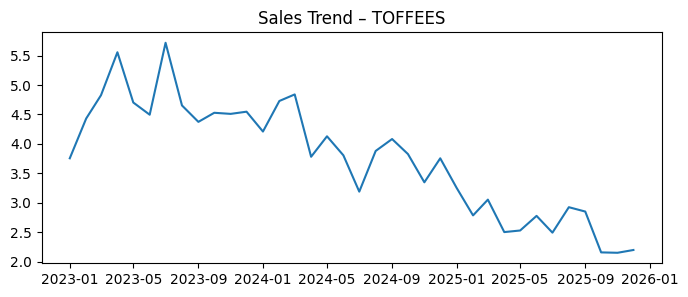

In [16]:
#Sales by Candy Type
for c in df_clean['Candy_Type'].unique():
    temp = df_clean[df_clean['Candy_Type'] == c]
    temp = temp.groupby('Month')['Sales_Volume'].sum()

    plt.figure(figsize=(8,3))
    plt.plot(temp)
    plt.title(f"Sales Trend – {c}")
    plt.show()

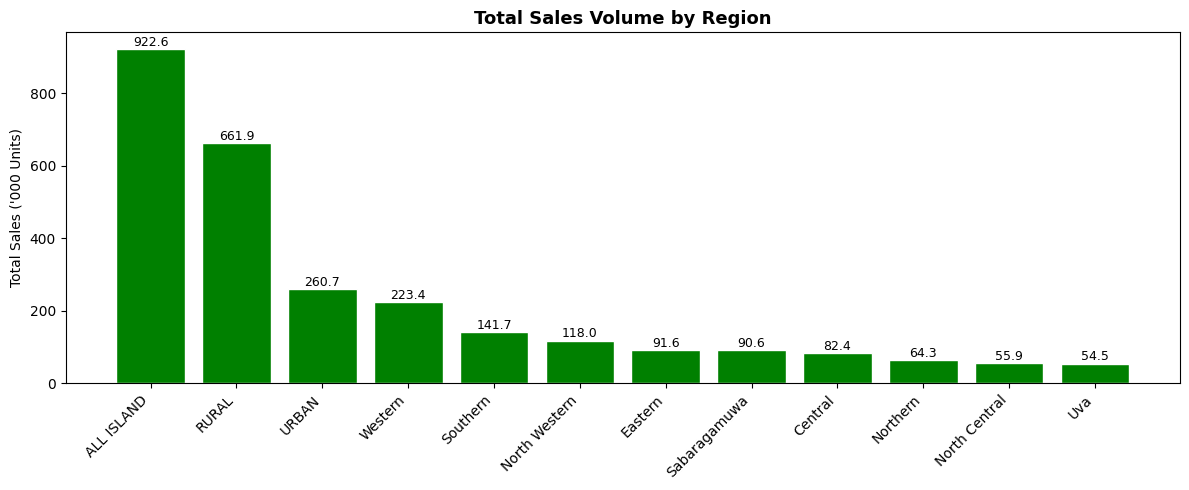

In [17]:
#Sales distribution by region
fig, ax = plt.subplots(figsize=(12, 5))
region_totals = df_clean.groupby('Region')['Sales_Volume'].sum().sort_values(ascending=False)
bars = ax.bar(region_totals.index, region_totals.values, color='green', edgecolor='white')
ax.set_title('Total Sales Volume by Region', fontsize=13, fontweight='bold')
ax.set_ylabel("Total Sales ('000 Units)")
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, region_totals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

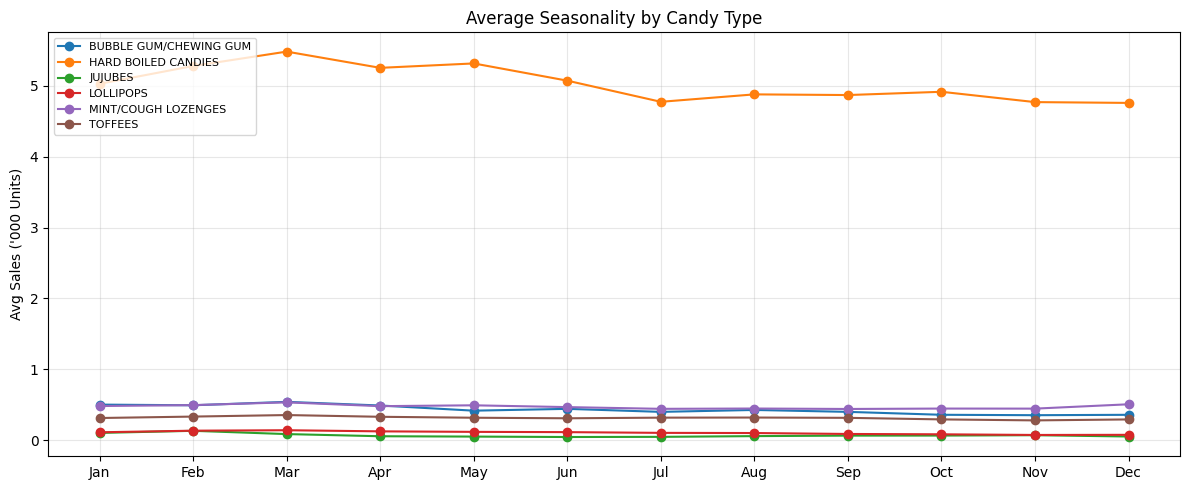

In [18]:
#Monthly seasonality (average sales by calendar month)
df_clean['CalMonth'] = df_clean['Month'].dt.month
monthly_avg = df_clean.groupby(['CalMonth', 'Candy_Type'])['Sales_Volume'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for candy in df_clean['Candy_Type'].unique():
    d = monthly_avg[monthly_avg['Candy_Type'] == candy]
    ax.plot(d['CalMonth'], d['Sales_Volume'], marker='o', label=candy)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average Seasonality by Candy Type')
ax.set_ylabel("Avg Sales ('000 Units)")
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
#Outlier detection — IQR-based per group
def flag_outliers(grp):
    Q1, Q3 = grp['Sales_Volume'].quantile(0.25), grp['Sales_Volume'].quantile(0.75)
    IQR = Q3 - Q1
    grp['is_outlier'] = (grp['Sales_Volume'] < Q1 - 1.5*IQR) | (grp['Sales_Volume'] > Q3 + 1.5*IQR)
    return grp

df_clean = df_clean.groupby(['Region','Candy_Type'], group_keys=False).apply(flag_outliers)
outlier_count = df_clean['is_outlier'].sum()
print(f'Outliers detected: {outlier_count} ({outlier_count/len(df_clean)*100:.1f}%)')
print(df_clean[df_clean['is_outlier']][['Month','Region','Candy_Type','Sales_Volume']].head(10))

Outliers detected: 65 (2.6%)
         Month         Region              Candy_Type  Sales_Volume
0   2023-01-01     ALL ISLAND  BUBBLE GUM/CHEWING GUM      3.019625
2   2023-03-01     ALL ISLAND  BUBBLE GUM/CHEWING GUM      3.251534
87  2024-04-01        Eastern  BUBBLE GUM/CHEWING GUM      0.212196
88  2024-05-01        Eastern  BUBBLE GUM/CHEWING GUM      0.217099
144 2023-01-01  North Western  BUBBLE GUM/CHEWING GUM      0.629112
146 2023-03-01  North Western  BUBBLE GUM/CHEWING GUM      0.870531
190 2023-11-01       Northern  BUBBLE GUM/CHEWING GUM      0.102875
195 2024-04-01       Northern  BUBBLE GUM/CHEWING GUM      0.124062
196 2024-05-01       Northern  BUBBLE GUM/CHEWING GUM      0.124877
197 2024-06-01       Northern  BUBBLE GUM/CHEWING GUM      0.172909


In [20]:
# Helper functions (All models) — 80/20 split
MIN_OBS = 24

def get_series(region, candy, freq='MS'):
    s = df_clean[
        (df_clean['Region']==region) & (df_clean['Candy_Type']==candy)
    ].set_index('Month')['Sales_Volume']
    s = s.resample(freq).sum()
    if (s == 0).mean() > 0.3:
        s = s.replace(0, np.nan)
    s = s.interpolate(method='time', limit=2).ffill().bfill()
    return s

def get_horizon(series):
    return max(1, int(len(series) * 0.2))

def train_test_split_ts(series, horizon=None):
    if horizon is None:
        horizon = get_horizon(series)
    return series[:-horizon], series[-horizon:]

def compute_metrics(actual, predicted, label=''):
    actual, predicted = np.array(actual), np.maximum(np.array(predicted), 0)
    return {
        'Model': label,
        'MAPE':  round(mean_absolute_percentage_error(actual, predicted), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(actual, predicted)), 4),
        'MAE':   round(mean_absolute_error(actual, predicted), 4)
    }

# All valid combos (≥24 months of data)
combos = [
    (r, c)
    for r in VALID_REGIONS
    for c in df_clean['Candy_Type'].unique()
    if len(get_series(r, c)) >= MIN_OBS
]
print(f'Valid combos: {len(combos)}')

# Preview split sizes
for r, c in combos[:5]:
    s = get_series(r, c)
    h = get_horizon(s)
    print(f'{r} – {c}: N={len(s)}, train={len(s)-h}, test={h}')


Valid combos: 72
ALL ISLAND – BUBBLE GUM/CHEWING GUM: N=36, train=29, test=7
ALL ISLAND – HARD BOILED CANDIES: N=36, train=29, test=7
ALL ISLAND – JUJUBES: N=36, train=29, test=7
ALL ISLAND – LOLLIPOPS: N=36, train=29, test=7
ALL ISLAND – MINT/COUGH LOZENGES: N=36, train=29, test=7


In [21]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'ADF_stat':   round(result[0], 4),
        'p_value':    round(result[1], 4),
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

def get_d(series):
    """Difference series until stationary. Loops until ADF p < 0.05."""
    s = series.copy().dropna()
    d = 0
    while True:
        p = adfuller(s.dropna(), autolag='AIC')[1]
        if p < 0.05:
            return d
        s = s.diff().dropna()
        d += 1
        if len(s.dropna()) < 10:
            return d

#loop
stationarity_results = []
for r, c in combos:
    series = get_series(r, c)
    level  = adf_test(series)
    diff   = adf_test(series.diff().dropna())
    d      = get_d(series)

    s = series.copy()
    for _ in range(d):
        s = s.diff().dropna()
    final_p = round(adfuller(s.dropna(), autolag='AIC')[1], 4)

    stationarity_results.append({
        'Region':           r,
        'Candy_Type':       c,
        'N':                len(series),
        'Level_Stationary': level['Stationary'],
        'Diff_Stationary':  diff['Stationary'],
        'Level_p':          level['p_value'],
        'Diff_p':           diff['p_value'],
        'Selected_d':       d,
        'Final_p':          final_p,
        'Stationary':       'Yes' if final_p < 0.05 else 'No'
    })

stat_df = pd.DataFrame(stationarity_results)
print('Stationary at level:', stat_df['Level_Stationary'].value_counts().to_dict())
print('Stationary after 1 diff:', stat_df['Diff_Stationary'].value_counts().to_dict())
print('Selected d distribution:', stat_df['Selected_d'].value_counts().to_dict())
stat_df.head(10)

Stationary at level: {'No': 47, 'Yes': 25}
Stationary after 1 diff: {'Yes': 65, 'No': 7}
Selected d distribution: {1: 42, 0: 25, 2: 4, 4: 1}


,Region,Candy_Type,N,Level_Stationary,Diff_Stationary,Level_p,Diff_p,Selected_d,Final_p,Stationary
0,ALL ISLAND,BUBBLE GUM/CHEWING GUM,36,No,Yes,0.1251,0.0000,1,0.0000,Yes
1,ALL ISLAND,HARD BOILED CANDIES,36,No,Yes,0.0727,0.0000,1,0.0000,Yes
2,ALL ISLAND,JUJUBES,36,No,Yes,0.0515,0.0000,1,0.0000,Yes
3,ALL ISLAND,LOLLIPOPS,36,No,Yes,0.2294,0.0000,1,0.0000,Yes
4,ALL ISLAND,MINT/COUGH LOZENGES,36,No,No,0.0551,0.1395,2,0.0043,Yes
5,ALL ISLAND,TOFFEES,36,No,Yes,0.9869,0.0000,1,0.0000,Yes
6,Central,BUBBLE GUM/CHEWING GUM,36,Yes,Yes,0.0488,0.0000,0,0.0488,Yes
7,Central,HARD BOILED CANDIES,36,Yes,Yes,0.0146,0.0000,0,0.0146,Yes
8,Central,JUJUBES,34,No,Yes,0.1542,0.0000,1,0.0000,Yes
9,Central,LOLLIPOPS,36,Yes,Yes,0.0173,0.0000,0,0.0173,Yes


In [22]:
# Check which series are still non-stationary
problem = stat_df[stat_df['Stationary'] == 'No']
print(f'Still non-stationary: {len(problem)} series')
print(problem[['Region', 'Candy_Type', 'N', 'Selected_d', 'Final_p']])

Still non-stationary: 0 series
Empty DataFrame
Columns: [Region, Candy_Type, N, Selected_d, Final_p]
Index: []


In [23]:
#Sarima Model

def get_d(series):
    #Difference series until stationary. Loops until ADF p < 0.05.
    s = series.copy().dropna()
    d = 0
    while True:
        p = adfuller(s.dropna(), autolag='AIC')[1]
        if p < 0.05:
            return d
        s = s.diff().dropna()
        d += 1
        if len(s.dropna()) < 10:  # safety stop
            return d

def run_sarima(region, candy, verbose=False):
    series = get_series(region, candy)
    if len(series) < MIN_OBS:
        return None

    # 80/20 split
    horizon = get_horizon(series)

    # EWMA pre-smoothing
    series = series.ewm(alpha=0.2).mean()

    train, test = train_test_split_ts(series, horizon)

    # Get d iteratively
    d = get_d(train)

    if verbose:
        print(f'{region} – {candy}: d={d}, horizon={horizon}')

    # Fit single SARIMA with iterative d — no grid search
    try:
        model = SARIMAX(
            train,
            order=(1, d, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
    except Exception as e:
        if verbose:
            print(f'  Failed: {e}')
        return None

    fc_obj   = model.get_forecast(steps=horizon)
    forecast = np.maximum(fc_obj.predicted_mean.values, 0)
    conf_int = fc_obj.conf_int()

    params = {'order': (1, d, 1), 'seasonal': (1, 1, 1, 12)}

    metrics = compute_metrics(test.values, forecast, 'SARIMA')
    metrics.update({
        'Region':     region,
        'Candy_Type': candy,
        'Best_Params': str(params),
        'AIC':        round(model.aic, 2),
        'd_used':     d
    })

    if verbose:
        print(f'  AIC={model.aic:.2f}  MAPE={metrics["MAPE"]:.2%}')

    return metrics, forecast, test, conf_int

Western – TOFFEES: d=3, horizon=7
  AIC=10.00  MAPE=10.53%

Metrics: {'Model': 'SARIMA', 'MAPE': 0.1053, 'RMSE': np.float64(0.028), 'MAE': 0.0261, 'Region': 'Western', 'Candy_Type': 'TOFFEES', 'Best_Params': "{'order': (1, 3, 1), 'seasonal': (1, 1, 1, 12)}", 'AIC': np.float64(10.0), 'd_used': 3}


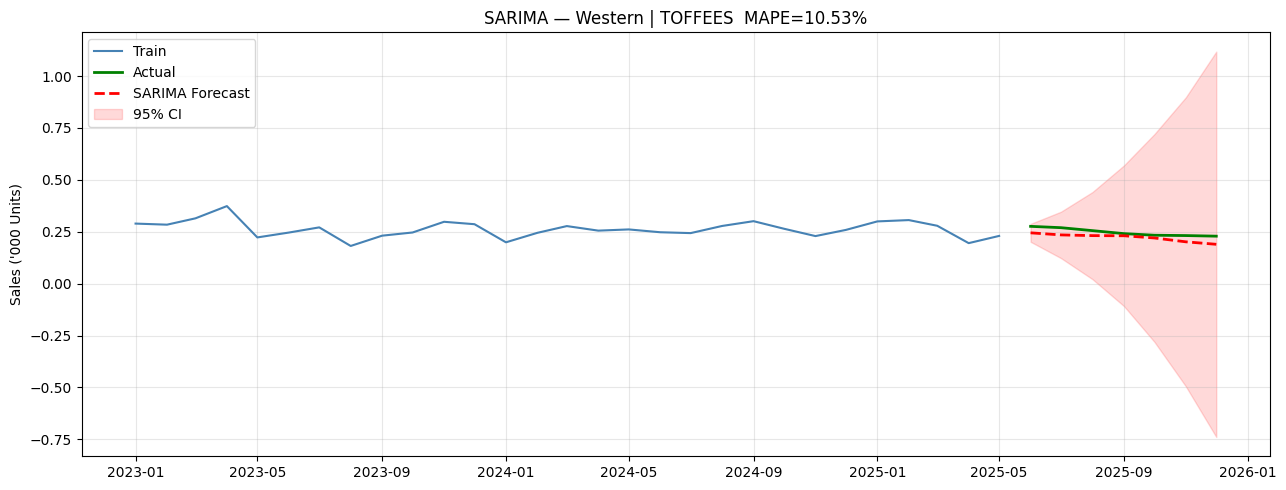

In [24]:
# Demo: SARIMA on Western | TOFFEES
demo_r, demo_c = 'Western', 'TOFFEES'
result_s = run_sarima(demo_r, demo_c, verbose=True)

if result_s:
    metrics_s, fc_s, test_s, ci_s = result_s  # 4 values now
    print('\nMetrics:', metrics_s)

    # Forecast plot with CI
    series_demo = get_series(demo_r, demo_c)
    horizon     = get_horizon(series_demo)
    train_d, _  = train_test_split_ts(series_demo, horizon)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_d.index, train_d.values,
            label='Train', color='steelblue')
    ax.plot(test_s.index, test_s.values,
            label='Actual', color='green', linewidth=2)
    ax.plot(test_s.index, fc_s,
            label='SARIMA Forecast', color='red',
            linestyle='--', linewidth=2)
    ax.fill_between(test_s.index,
                    ci_s.iloc[:, 0], ci_s.iloc[:, 1],
                    alpha=0.15, color='red', label='95% CI')
    ax.set_title(
        f'SARIMA — {demo_r} | {demo_c}  '
        f'MAPE={metrics_s["MAPE"]:.2%}'
    )
    ax.set_ylabel("Sales ('000 Units)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



Training length: 29
d selected: 3
Residual length: 29


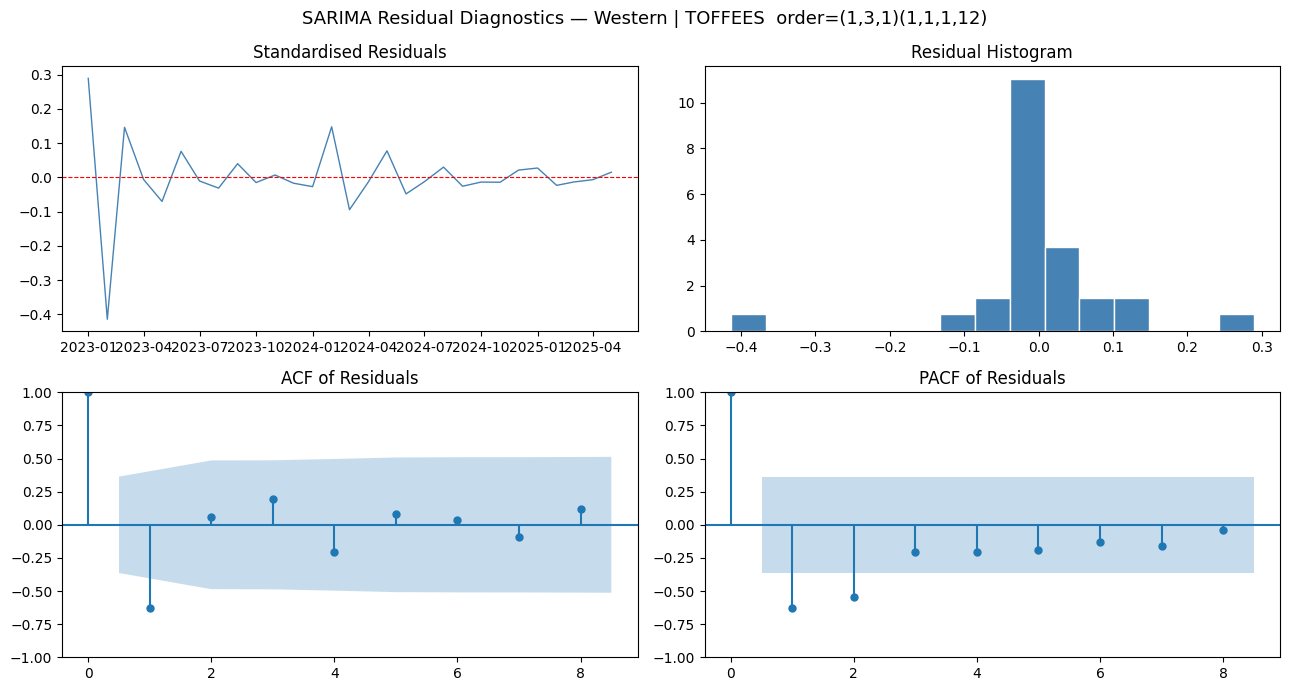

In [25]:
# Residual diagnostics
series_d    = get_series(demo_r, demo_c)
series_s    = series_d.ewm(alpha=0.2).mean()
horizon     = get_horizon(series_s)
train_d2, _ = train_test_split_ts(series_s, horizon)
d           = get_d(train_d2)

print(f'Training length: {len(train_d2)}')
print(f'd selected: {d}')

final_m = SARIMAX(
    train_d2,
    order=(1, d, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Residuals
resid = final_m.resid.dropna()
print(f'Residual length: {len(resid)}')

# Plot manually instead of plot_diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# 1. Residuals over time
axes[0,0].plot(resid.index, resid.values, color='steelblue', linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0,0].set_title('Standardised Residuals')

# 2. Histogram
axes[0,1].hist(resid, bins=15, color='steelblue', edgecolor='white', density=True)
axes[0,1].set_title('Residual Histogram')

# 3. ACF
safe_lags = max(1, min(10, len(resid) // 3 - 1))
plot_acf(resid, ax=axes[1,0], lags=safe_lags, title='ACF of Residuals')

# 4. PACF
plot_pacf(resid, ax=axes[1,1], lags=safe_lags, title='PACF of Residuals')

plt.suptitle(
    f'SARIMA Residual Diagnostics — {demo_r} | {demo_c}  '
    f'order=(1,{d},1)(1,1,1,12)',
    fontsize=13
)
plt.tight_layout()
plt.show()

In [26]:
#Running SARIMA on all valid combos
sarima_results = []
for r, c in combos:
    res = run_sarima(r, c)
    if res:
        sarima_results.append(res[0])
    else:
        print(f'SARIMA skipped: {r} – {c}')

sarima_df = pd.DataFrame(sarima_results)
print(f'\nSARIMA done: {len(sarima_df)} combos')
print(sarima_df[['Region','Candy_Type','MAPE','RMSE','MAE','Best_Params','d_used']].sort_values('MAPE').head(10))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


SARIMA done: 72 combos
           Region              Candy_Type    MAPE    RMSE     MAE  \
1      ALL ISLAND     HARD BOILED CANDIES  0.0210  0.4611  0.4055   
25  North Central     HARD BOILED CANDIES  0.0273  0.0383  0.0304   
65          RURAL                 TOFFEES  0.0516  0.0350  0.0311   
43        Western     HARD BOILED CANDIES  0.0570  0.3828  0.2879   
27  North Central               LOLLIPOPS  0.0599  0.0011  0.0010   
4      ALL ISLAND     MINT/COUGH LOZENGES  0.0816  0.2120  0.1270   
15        Eastern               LOLLIPOPS  0.0869  0.0029  0.0025   
50   Sabaragamuwa                 JUJUBES  0.0903  0.0088  0.0067   
0      ALL ISLAND  BUBBLE GUM/CHEWING GUM  0.1036  0.1692  0.1359   
47        Western                 TOFFEES  0.1053  0.0280  0.0261   

                                        Best_Params  d_used  
1   {'order': (1, 2, 1), 'seasonal': (1, 1, 1, 12)}       2  
25  {'order': (1, 0, 1), 'seasonal': (1, 1, 1, 12)}       0  
65  {'order': (1, 2, 1), 'seas

In [27]:
#Holt winters model
def hw_full_search(train, verbose=False):
    best_aic, best_model, best_params = np.inf, None, None
    results = []

    for trend in ['add', 'mul', None]:
        for seasonal in ['add', 'mul']:
            damped_options = [True, False] if trend is not None else [False]
            for damped in damped_options:
                for boxcox in [True, False]:
                    try:
                        m = ExponentialSmoothing(
                            train,
                            trend=trend,
                            seasonal=seasonal,
                            seasonal_periods=12,
                            damped_trend=damped,
                            use_boxcox=boxcox,
                            initialization_method='estimated'
                        ).fit(optimized=True, remove_bias=True)

                        results.append({
                            'trend': trend, 'seasonal': seasonal,
                            'damped': damped, 'boxcox': boxcox,
                            'AIC': round(m.aic, 2), 'SSE': round(m.sse, 4)
                        })
                        if m.aic < best_aic:
                            best_aic   = m.aic
                            best_model = m
                            best_params = {
                                'trend': trend, 'seasonal': seasonal,
                                'damped': damped, 'boxcox': boxcox
                            }
                    except:
                        continue

    results_df = pd.DataFrame(results)
    if results_df.empty or 'AIC' not in results_df.columns:
        return None, None, np.inf, results_df

    results_df = results_df.sort_values('AIC').reset_index(drop=True)
    if verbose and not results_df.empty:
        print('Top 5 Holt-Winters configs:')
        print(results_df.head())
    return best_model, best_params, best_aic, results_df


def run_holt_winters(region, candy, verbose=False):
    series = get_series(region, candy)
    if len(series) < MIN_OBS:
        return None

    # 80/20 split
    horizon = get_horizon(series)
    train, test = train_test_split_ts(series, horizon)

    model, params, aic, grid_df = hw_full_search(train, verbose=verbose)
    if model is None:
        return None

    forecast = np.maximum(model.forecast(horizon), 0) * 0.95

    # Prediction intervals via simulation
    sim   = model.simulate(horizon, repetitions=1000, error='add')
    lower = np.percentile(sim, 2.5,  axis=1)
    upper = np.percentile(sim, 97.5, axis=1)

    metrics = compute_metrics(test.values, forecast, 'Holt-Winters')
    metrics.update({
        'Region':     region,
        'Candy_Type': candy,
        'Best_Params': str(params),
        'AIC':        round(aic, 2)
    })
    return metrics, forecast, test, lower, upper, grid_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Top 5 Holt-Winters configs:
  trend seasonal  damped  boxcox     AIC     SSE
0  None      mul   False   False -165.53  0.0367
1  None      add   False   False -165.53  0.0367
2  None      add   False    True -165.45  0.0368
3   mul      mul   False   False -163.12  0.0347
4   add      mul   False   False -163.10  0.0347

Best params: {'trend': None, 'seasonal': 'add', 'damped': False, 'boxcox': False}
Metrics: {'MAPE': 0.1917, 'RMSE': np.float64(0.0614), 'MAE': 0.0469}


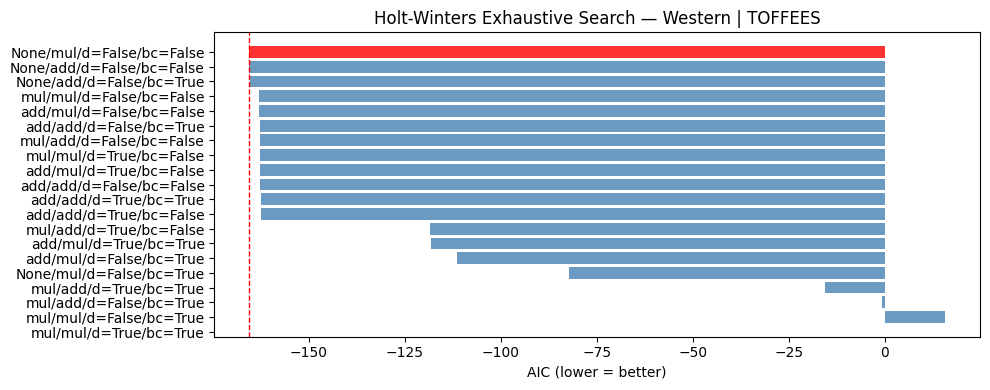

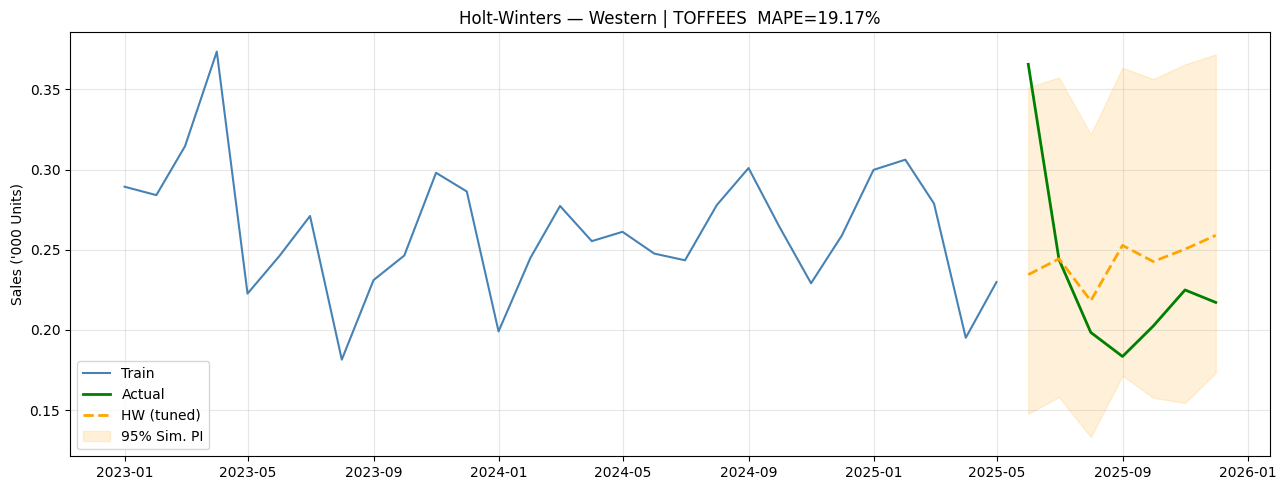

In [28]:
# --- Demo ---
# Demo — Holt-Winters
result_hw = run_holt_winters(demo_r, demo_c, verbose=True)

if result_hw:
    metrics_hw, fc_hw, test_hw, lo_hw, hi_hw, grid_hw = result_hw
    print('\nBest params:', metrics_hw['Best_Params'])
    print('Metrics:', {k:v for k,v in metrics_hw.items() if k in ['MAPE','RMSE','MAE']})

    # AIC bar chart
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = [f"{r['trend']}/{r['seasonal']}/d={r['damped']}/bc={r['boxcox']}"
              for _, r in grid_hw.iterrows()]
    colors = ['red' if i==0 else 'steelblue' for i in range(len(grid_hw))]
    ax.barh(labels[::-1], grid_hw['AIC'].values[::-1],
            color=colors[::-1], alpha=0.8)
    ax.set_xlabel('AIC (lower = better)')
    ax.set_title(f'Holt-Winters Exhaustive Search — {demo_r} | {demo_c}')
    ax.axvline(grid_hw['AIC'].min(), color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

    # Forecast plot — raw series for consistent scale
    series_d        = get_series(demo_r, demo_c)
    horizon         = get_horizon(series_d)
    train_d, test_d = train_test_split_ts(series_d, horizon)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_d.index, train_d.values,
            label='Train', color='steelblue')
    ax.plot(test_d.index, test_d.values,
            label='Actual', color='green', linewidth=2)
    ax.plot(test_d.index, fc_hw,
            label='HW (tuned)', color='orange', linestyle='--', linewidth=2)
    ax.fill_between(test_d.index, lo_hw, hi_hw,
                    alpha=0.15, color='orange', label='95% Sim. PI')
    ax.set_title(
        f'Holt-Winters — {demo_r} | {demo_c}  MAPE={metrics_hw["MAPE"]:.2%}'
    )
    ax.set_ylabel("Sales ('000 Units)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [29]:
hw_results = []
for r, c in combos:
    res = run_holt_winters(r, c)
    if res:
        hw_results.append(res[0])
    else:
        print(f'HW skipped: {r} – {c}')

hw_df = pd.DataFrame(hw_results)
print(f'Holt-Winters done: {len(hw_df)} combos')
print(hw_df[['Region','Candy_Type','MAPE','RMSE','MAE','Best_Params']].sort_values('MAPE').head(10))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

HW skipped: Northern – JUJUBES
HW skipped: Northern – LOLLIPOPS


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

Holt-Winters done: 70 combos
           Region              Candy_Type    MAPE    RMSE     MAE  \
59          RURAL     HARD BOILED CANDIES  0.0717  1.0957  0.9466   
1      ALL ISLAND     HARD BOILED CANDIES  0.0778  1.5291  1.4042   
5      ALL ISLAND                 TOFFEES  0.0781  0.0909  0.0689   
41        Western     HARD BOILED CANDIES  0.0819  0.4756  0.4052   
64          URBAN  BUBBLE GUM/CHEWING GUM  0.0873  0.0285  0.0230   
23  North Central     HARD BOILED CANDIES  0.0968  0.1323  0.1056   
65          URBAN     HARD BOILED CANDIES  0.1219  0.6793  0.5883   
58          RURAL  BUBBLE GUM/CHEWING GUM  0.1608  0.1833  0.1558   
34       Southern  BUBBLE GUM/CHEWING GUM  0.1620  0.0673  0.0446   
35       Southern     HARD BOILED CANDIES  0.1645  0.5629  0.4399   

                                          Best_Params  
59  {'trend': None, 'seasonal': 'mul', 'damped': F...  
1   {'trend': None, 'seasonal': 'mul', 'damped': F...  
5   {'trend': 'add', 'seasonal': 'mul', 'da

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [30]:
# LSTM Model
LOOKBACK = 12  # months of history used as input

def create_sequences(data, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


def prepare_lstm_data(series, lookback=LOOKBACK):
    horizon = get_horizon(series)  # 80/20 dynamic horizon
    values  = series.values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(values)

    # Reserve last horizon points for testing
    train_scaled = scaled[:-horizon]
    test_scaled  = scaled[-horizon:]

    X_train, y_train = create_sequences(train_scaled, lookback)

    # Reshape for LSTM: (samples, timesteps, features)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

    return X_train, y_train, test_scaled, scaler, train_scaled, horizon

In [31]:
# Baseline LSTM
def build_baseline_lstm(lookback=LOOKBACK):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model


def lstm_rolling_forecast(model, train_scaled, scaler, horizon, lookback=LOOKBACK):
    #Multi-step forecast using rolling autoregressive strategy
    input_seq   = list(train_scaled[-lookback:, 0])
    predictions = []

    for _ in range(horizon):
        x    = np.array(input_seq[-lookback:]).reshape(1, lookback, 1)
        pred = model.predict(x, verbose=0)[0, 0]
        predictions.append(pred)
        input_seq.append(pred)

    preds_rescaled = scaler.inverse_transform(
        np.array(predictions).reshape(-1, 1)
    ).flatten()
    return np.maximum(preds_rescaled, 0)


def run_baseline_lstm(region, candy, epochs=80, batch_size=8):
    series = get_series(region, candy)
    if len(series) < MIN_OBS + LOOKBACK:
        return None

    # 80/20 split — horizon now returned from prepare_lstm_data
    X_train, y_train, test_scaled, scaler, train_scaled, horizon = \
        prepare_lstm_data(series)

    test_actual = scaler.inverse_transform(test_scaled).flatten()

    model     = build_baseline_lstm()
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
    ]
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
              validation_split=0.15, callbacks=callbacks, verbose=0)

    predictions = lstm_rolling_forecast(model, train_scaled, scaler, horizon)
    metrics     = compute_metrics(test_actual, predictions, 'LSTM_Baseline')
    metrics.update({'Region': region, 'Candy_Type': candy})
    return metrics, predictions, test_actual, model, scaler

Baseline LSTM metrics: {'Model': 'LSTM_Baseline', 'MAPE': 0.1498, 'RMSE': np.float64(0.0553), 'MAE': 0.038, 'Region': 'Western', 'Candy_Type': 'TOFFEES'}


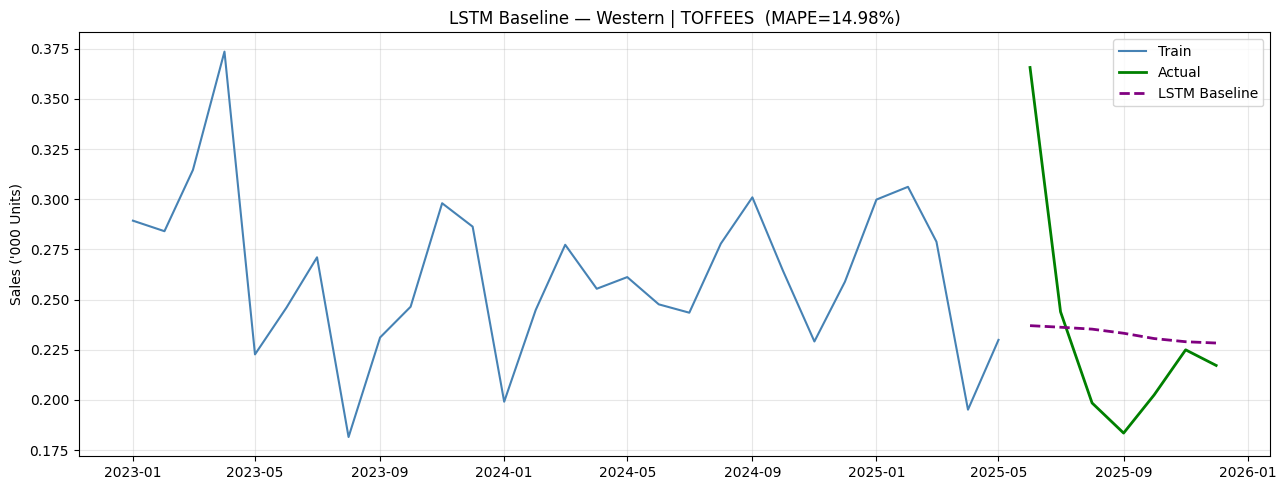

In [32]:
# Run baseline LSTM on Western | TOFFEES
DEMO_REGION, DEMO_CANDY = 'Western', 'TOFFEES'

result = run_baseline_lstm(DEMO_REGION, DEMO_CANDY)
if result:
    metrics_bl, preds_bl, test_bl, model_bl, scaler_bl = result
    print('Baseline LSTM metrics:', metrics_bl)

    series  = get_series(DEMO_REGION, DEMO_CANDY)
    horizon = get_horizon(series)
    train_ser, test_ser = train_test_split_ts(series, horizon)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_ser.index, train_ser.values,
            label='Train', color='steelblue')
    ax.plot(test_ser.index, test_ser.values,
            label='Actual', color='green', linewidth=2)
    ax.plot(test_ser.index, preds_bl,
            label='LSTM Baseline', color='purple',
            linestyle='--', linewidth=2)
    ax.set_title(
        f'LSTM Baseline — {DEMO_REGION} | {DEMO_CANDY}  '
        f'(MAPE={metrics_bl["MAPE"]:.2%})'
    )
    ax.set_ylabel("Sales ('000 Units)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
def build_tunable_lstm(hp, lookback=LOOKBACK):
    model = Sequential()

    n_layers = hp.Int('n_lstm_layers', min_value=1, max_value=3)
    units_1  = hp.Int('units_1', min_value=32, max_value=256, step=32)
    dropout  = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    lr       = hp.Choice('lr', values=[1e-2, 1e-3, 5e-4, 1e-4])

    model.add(LSTM(units_1, return_sequences=(n_layers > 1), input_shape=(lookback, 1)))
    model.add(Dropout(dropout))

    if n_layers >= 2:
        units_2 = hp.Int('units_2', min_value=16, max_value=128, step=16)
        model.add(LSTM(units_2, return_sequences=(n_layers > 2)))
        model.add(Dropout(dropout))

    if n_layers >= 3:
        units_3 = hp.Int('units_3', min_value=8, max_value=64, step=8)
        model.add(LSTM(units_3, return_sequences=False))
        model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model


def run_tuned_lstm(region, candy, max_trials=15, epochs=80):
    series = get_series(region, candy)
    if len(series) < MIN_OBS + LOOKBACK:
        return None

    # 80/20 split — unpack horizon from prepare_lstm_data
    X_train, y_train, test_scaled, scaler, train_scaled, horizon = \
        prepare_lstm_data(series)

    test_actual = scaler.inverse_transform(test_scaled).flatten()

    tuner = kt.BayesianOptimization(
        lambda hp: build_tunable_lstm(hp),
        objective='val_loss',
        max_trials=max_trials,
        overwrite=True,
        directory='kt_results',
        project_name=f'{region}_{candy}'.replace(' ', '_').replace('/', '_')
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]

    tuner.search(X_train, y_train, epochs=epochs, batch_size=8,
                 validation_split=0.15, callbacks=callbacks, verbose=0)

    best_hps   = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.hypermodel.build(best_hps)

    # Final training with best HPs
    best_model.fit(X_train, y_train, epochs=epochs, batch_size=8,
                   validation_split=0.15, callbacks=callbacks, verbose=0)

    predictions = lstm_rolling_forecast(best_model, train_scaled, scaler, horizon)
    metrics     = compute_metrics(test_actual, predictions, 'LSTM_Tuned')
    metrics.update({
        'Region':      region,
        'Candy_Type':  candy,
        'Best_Params': str(best_hps.values)
    })
    return metrics, predictions, test_actual, best_model, best_hps

Running Keras Tuner on Western – TOFFEES ...

=== Tuned LSTM Results ===
Best Hyperparameters: {'n_lstm_layers': 3, 'units_1': 192, 'dropout': 0.2, 'lr': 0.0001, 'units_2': 112, 'units_3': 16}
Metrics: {'Model': 'LSTM_Tuned', 'MAPE': 0.1592, 'RMSE': np.float64(0.0561), 'MAE': 0.0399, 'Region': 'Western', 'Candy_Type': 'TOFFEES', 'Best_Params': "{'n_lstm_layers': 3, 'units_1': 192, 'dropout': 0.2, 'lr': 0.0001, 'units_2': 112, 'units_3': 16}"}


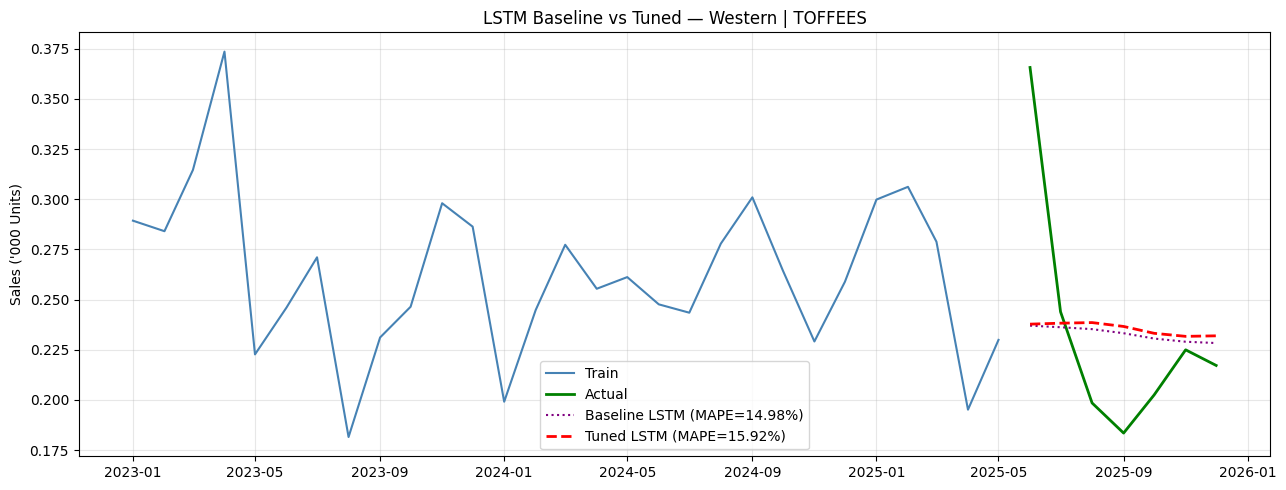

In [34]:
# Hypertuned LSTM on demo combo
print(f'Running Keras Tuner on {DEMO_REGION} – {DEMO_CANDY} ...')

tuned_result = run_tuned_lstm(DEMO_REGION, DEMO_CANDY, max_trials=15, epochs=80)

if tuned_result:
    metrics_t, preds_t, test_t, model_t, best_hps = tuned_result

    print('\n=== Tuned LSTM Results ===')
    print('Best Hyperparameters:', best_hps.values)
    print('Metrics:', metrics_t)

    # Compare baseline vs tuned
    series  = get_series(DEMO_REGION, DEMO_CANDY)
    horizon = get_horizon(series)
    train_ser, test_ser = train_test_split_ts(series, horizon)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_ser.index, train_ser.values,
            label='Train', color='steelblue')
    ax.plot(test_ser.index, test_ser.values,
            label='Actual', color='green', linewidth=2)
    if result:
        ax.plot(test_ser.index, preds_bl,
                label=f'Baseline LSTM (MAPE={metrics_bl["MAPE"]:.2%})',
                color='purple', linestyle=':', linewidth=1.5)
    ax.plot(test_ser.index, preds_t,
            label=f'Tuned LSTM (MAPE={metrics_t["MAPE"]:.2%})',
            color='red', linestyle='--', linewidth=2)
    ax.set_title(f'LSTM Baseline vs Tuned — {DEMO_REGION} | {DEMO_CANDY}')
    ax.set_ylabel("Sales ('000 Units)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [35]:
# Full model comparison — 3 models (SARIMA, Holt-Winters, LSTM)

compare_r, compare_c = 'ALL ISLAND', 'HARD BOILED CANDIES'

all_model_results = []

res = run_sarima(compare_r, compare_c)
if res: all_model_results.append(res[0])

res = run_holt_winters(compare_r, compare_c)
if res: all_model_results.append(res[0])

res = run_baseline_lstm(compare_r, compare_c)
if res: all_model_results.append(res[0])

res = run_tuned_lstm(compare_r, compare_c, max_trials=15, epochs=80)
if res: all_model_results.append(res[0])

comp_df = pd.DataFrame(all_model_results)[['Model','MAPE','RMSE','MAE']].sort_values('MAPE').reset_index(drop=True)
comp_df['Rank'] = comp_df.index + 1
print(f'=== Model Comparison: {compare_r} | {compare_c} ===')
print(comp_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== Model Comparison: ALL ISLAND | HARD BOILED CANDIES ===
        Model   MAPE   RMSE    MAE  Rank
       SARIMA 0.0210 0.4611 0.4055     1
 Holt-Winters 0.0778 1.5291 1.4042     2
LSTM_Baseline 0.1542 2.8758 2.7035     3
   LSTM_Tuned 0.1808 3.3869 3.1646     4


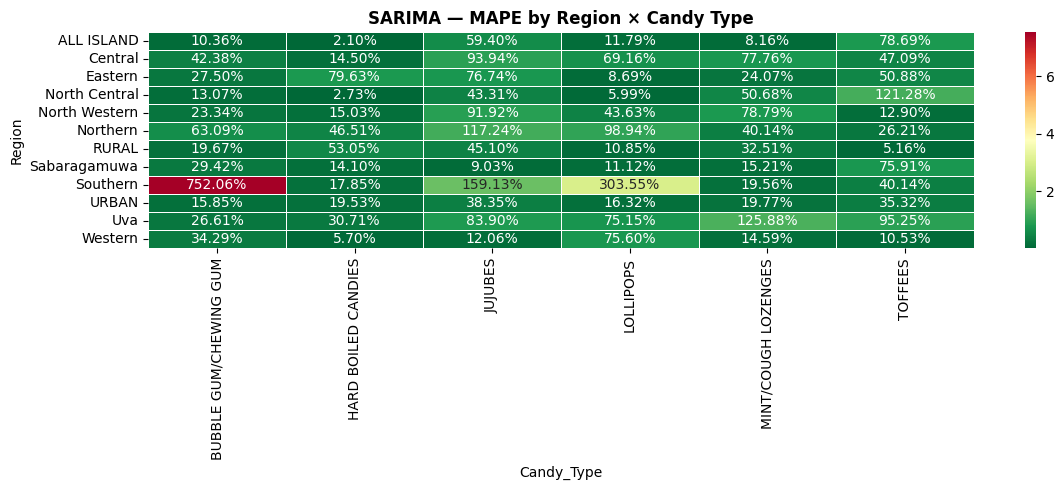

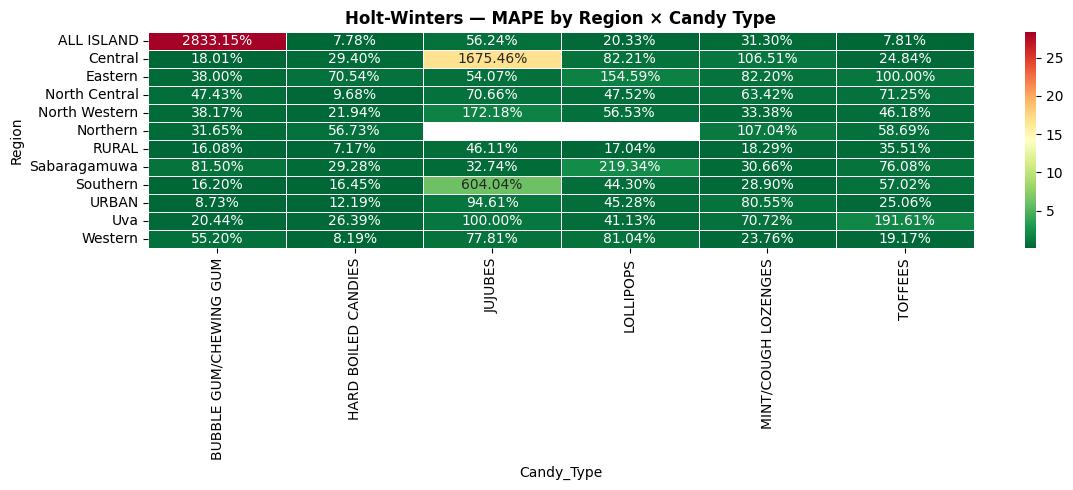

In [36]:
# MAPE heatmaps for all 3 traditional models across Region × Candy
all_trad = pd.concat([
    sarima_df[['Region','Candy_Type','Model','MAPE']],
    hw_df[['Region','Candy_Type','Model','MAPE']],
], ignore_index=True)

for model_name in ['SARIMA','Holt-Winters']:
    subset = all_trad[all_trad['Model']==model_name]
    pivot  = subset.pivot(index='Region', columns='Candy_Type', values='MAPE')
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax, linewidths=0.4)
    ax.set_title(f'{model_name} — MAPE by Region × Candy Type', fontweight='bold')
    plt.tight_layout()
    plt.show()

LSTM done: 66 combos


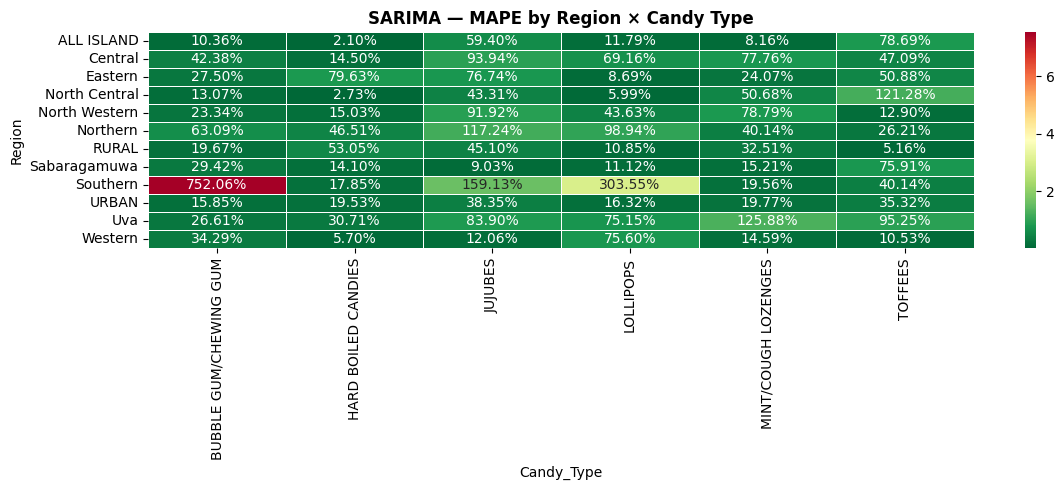

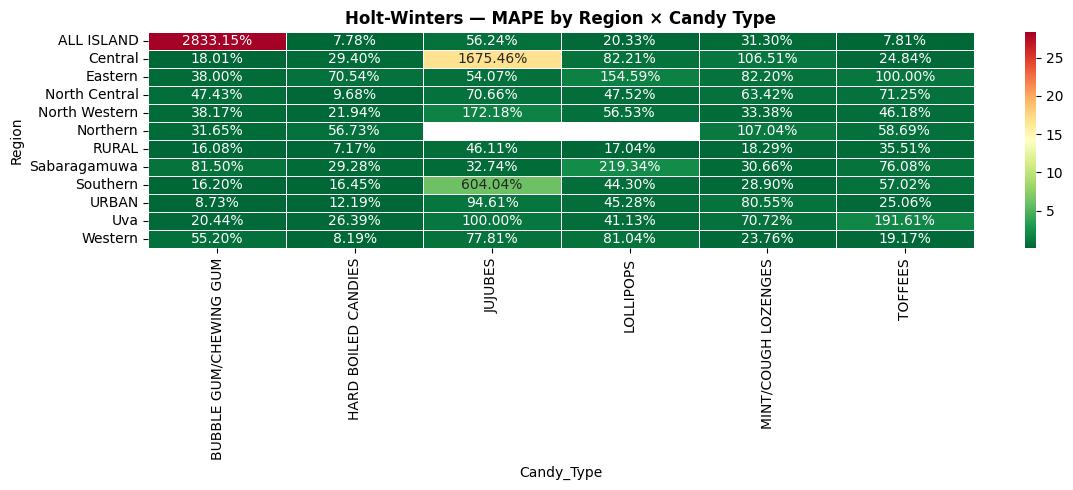

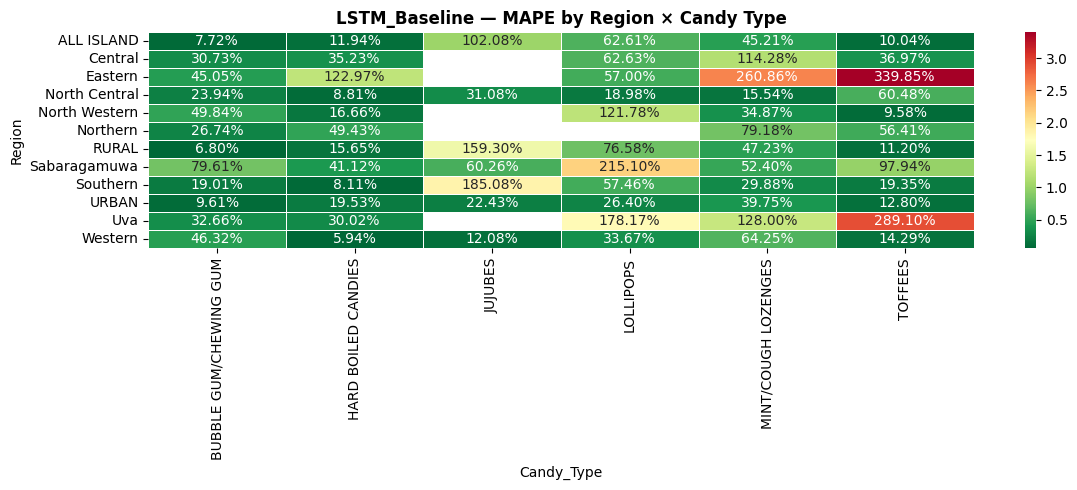

Best model per combo (top 20):
       Region             Candy_Type         Model   MAPE
   ALL ISLAND    HARD BOILED CANDIES        SARIMA 0.0210
North Central    HARD BOILED CANDIES        SARIMA 0.0273
        RURAL                TOFFEES        SARIMA 0.0516
      Western    HARD BOILED CANDIES        SARIMA 0.0570
North Central              LOLLIPOPS        SARIMA 0.0599
        RURAL BUBBLE GUM/CHEWING GUM LSTM_Baseline 0.0680
        RURAL    HARD BOILED CANDIES  Holt-Winters 0.0717
   ALL ISLAND BUBBLE GUM/CHEWING GUM LSTM_Baseline 0.0772
   ALL ISLAND                TOFFEES  Holt-Winters 0.0781
     Southern    HARD BOILED CANDIES LSTM_Baseline 0.0811
   ALL ISLAND    MINT/COUGH LOZENGES        SARIMA 0.0816
      Eastern              LOLLIPOPS        SARIMA 0.0869
        URBAN BUBBLE GUM/CHEWING GUM  Holt-Winters 0.0873
 Sabaragamuwa                JUJUBES        SARIMA 0.0903
North Western                TOFFEES LSTM_Baseline 0.0958
      Western                TOFFEES     

In [37]:
# Collect LSTM results for all combos
lstm_results = []
for r, c in combos:
    res = run_baseline_lstm(r, c)
    if res:
        lstm_results.append(res[0])

lstm_df = pd.DataFrame(lstm_results)
print(f'LSTM done: {len(lstm_df)} combos')

# MAPE heatmaps for all 3 models
all_trad = pd.concat([
    sarima_df[['Region', 'Candy_Type', 'Model', 'MAPE']],
    hw_df[['Region', 'Candy_Type', 'Model', 'MAPE']],
    lstm_df[['Region', 'Candy_Type', 'Model', 'MAPE']],
], ignore_index=True)

for model_name in ['SARIMA', 'Holt-Winters', 'LSTM_Baseline']:
    subset = all_trad[all_trad['Model'] == model_name]
    pivot  = subset.pivot(index='Region', columns='Candy_Type', values='MAPE')
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.2%',
                cmap='RdYlGn_r', ax=ax, linewidths=0.4)
    ax.set_title(f'{model_name} — MAPE by Region × Candy Type',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

# Best model per combo
best_per_combo = all_trad.loc[
    all_trad.groupby(['Region', 'Candy_Type'])['MAPE'].idxmin()
].sort_values('MAPE').reset_index(drop=True)

print('Best model per combo (top 20):')
print(best_per_combo.head(20).to_string(index=False))

print('\nModel win count:')
print(best_per_combo['Model'].value_counts())

Best model per combo (top 20):
       Region             Candy_Type         Model   MAPE
   ALL ISLAND    HARD BOILED CANDIES        SARIMA 0.0210
North Central    HARD BOILED CANDIES        SARIMA 0.0273
        RURAL                TOFFEES        SARIMA 0.0516
      Western    HARD BOILED CANDIES        SARIMA 0.0570
North Central              LOLLIPOPS        SARIMA 0.0599
        RURAL BUBBLE GUM/CHEWING GUM LSTM_Baseline 0.0680
        RURAL    HARD BOILED CANDIES  Holt-Winters 0.0717
   ALL ISLAND BUBBLE GUM/CHEWING GUM LSTM_Baseline 0.0772
   ALL ISLAND                TOFFEES  Holt-Winters 0.0781
     Southern    HARD BOILED CANDIES LSTM_Baseline 0.0811
   ALL ISLAND    MINT/COUGH LOZENGES        SARIMA 0.0816
      Eastern              LOLLIPOPS        SARIMA 0.0869
        URBAN BUBBLE GUM/CHEWING GUM  Holt-Winters 0.0873
 Sabaragamuwa                JUJUBES        SARIMA 0.0903
North Western                TOFFEES LSTM_Baseline 0.0958
      Western                TOFFEES     

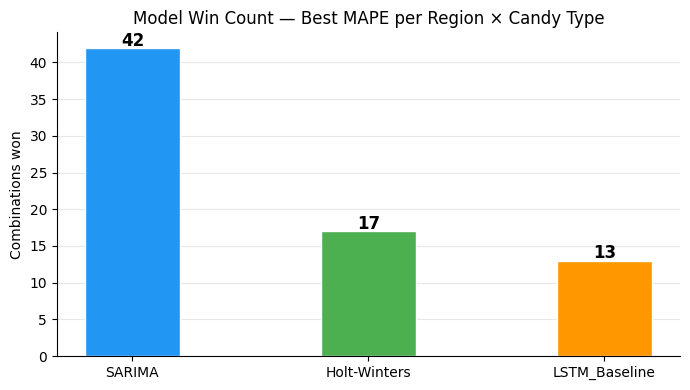

In [38]:
# Best model per combo
best_per_combo = all_trad.loc[
    all_trad.groupby(['Region', 'Candy_Type'])['MAPE'].idxmin()
].sort_values('MAPE').reset_index(drop=True)

print('Best model per combo (top 20):')
print(best_per_combo.head(20).to_string(index=False))

print('\nModel win count:')
print(best_per_combo['Model'].value_counts())

# Win count bar chart
win_counts = best_per_combo['Model'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800'][:len(win_counts)]
bars = ax.bar(win_counts.index, win_counts.values,
              color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, win_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Combinations won')
ax.set_title('Model Win Count — Best MAPE per Region × Candy Type')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

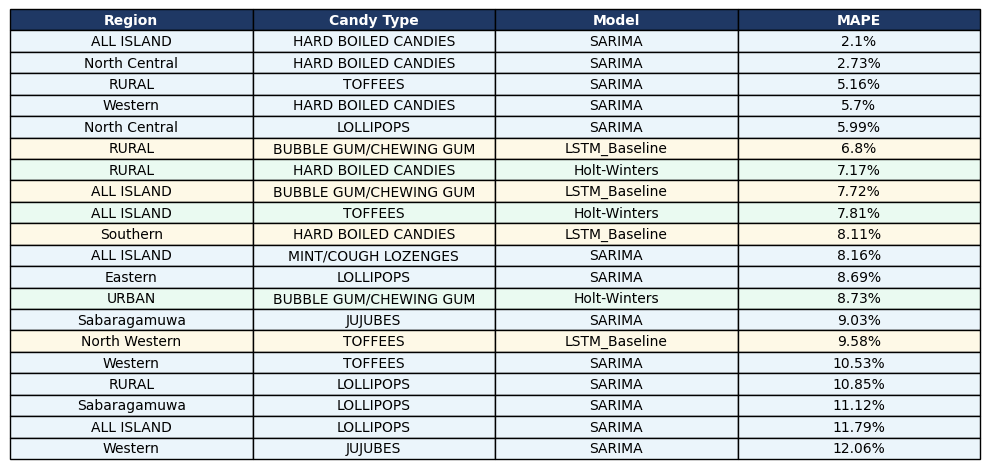

In [39]:
#Top 20 best model per combo
top20 = best_per_combo.head(20)[['Region', 'Candy_Type', 'Model', 'MAPE']].copy()
top20['MAPE'] = (top20['MAPE'] * 100).round(2).astype(str) + '%'
top20.index = range(1, 21)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

colors_row = []
for model in best_per_combo.head(20)['Model']:
    if model == 'SARIMA':
        colors_row.append(['#EBF5FB', '#EBF5FB', '#EBF5FB', '#EBF5FB'])
    elif model == 'Holt-Winters':
        colors_row.append(['#EAFAF1', '#EAFAF1', '#EAFAF1', '#EAFAF1'])
    else:
        colors_row.append(['#FEF9E7', '#FEF9E7', '#FEF9E7', '#FEF9E7'])

table = ax.table(
    cellText=top20.values,
    colLabels=['Region', 'Candy Type', 'Model', 'MAPE'],
    cellLoc='center',
    loc='center',
    cellColours=colors_row
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Style header
for j in range(4):
    table[0, j].set_facecolor('#1F3864')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('table4_top20_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

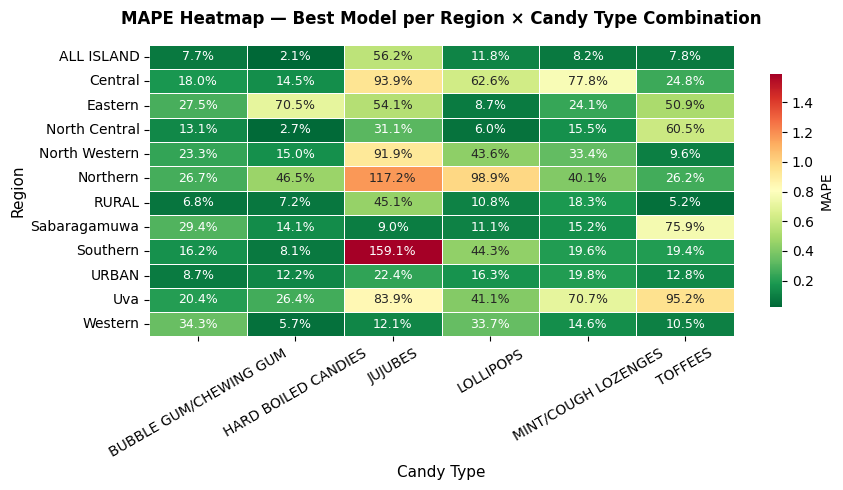

In [40]:
#MAPE heatmap — best model per Region × Candy Type
pivot = best_per_combo.pivot(index='Region', columns='Candy_Type', values='MAPE')

fig, ax = plt.subplots(figsize=(9, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',
    cmap='RdYlGn_r',
    ax=ax,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'MAPE', 'shrink': 0.8},
    annot_kws={'size': 9}
)

ax.set_title(
    'MAPE Heatmap — Best Model per Region × Candy Type Combination',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Candy Type', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('figure19_mape_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


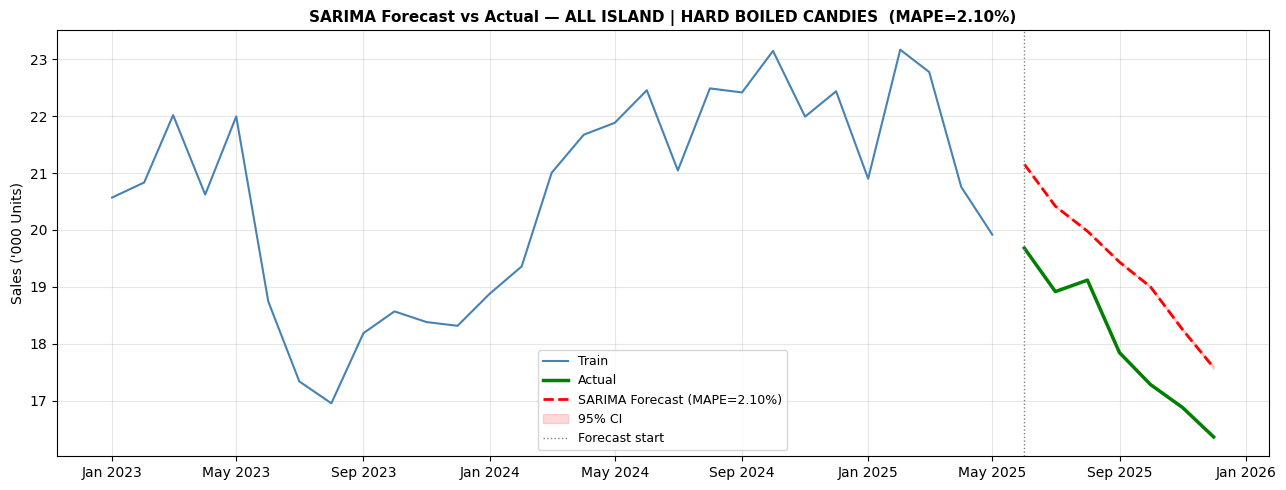

MAPE:  2.10%
RMSE:  0.4611
MAE:   0.4055
d used: 2


In [41]:
# Forecast vs Actual — ALL ISLAND | HARD BOILED CANDIES (SARIMA)
r, c = 'ALL ISLAND', 'HARD BOILED CANDIES'

res = run_sarima(r, c)
if res:
    metrics_ai, fc_ai, test_ai, ci_ai = res

    series_ai        = get_series(r, c)
    horizon_ai       = get_horizon(series_ai)
    train_ai, test_d = train_test_split_ts(series_ai, horizon_ai)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_ai.index, train_ai.values,
            label='Train', color='steelblue', linewidth=1.5)
    ax.plot(test_d.index, test_d.values,
            label='Actual', color='green', linewidth=2.5)
    ax.plot(test_ai.index, fc_ai,
            label=f'SARIMA Forecast (MAPE={metrics_ai["MAPE"]:.2%})',
            color='red', linestyle='--', linewidth=2)
    ax.fill_between(test_ai.index, ci_ai.iloc[:, 0], ci_ai.iloc[:, 1],
                    alpha=0.15, color='red', label='95% CI')
    ax.axvline(test_ai.index[0], color='gray',
               linestyle=':', linewidth=1, label='Forecast start')
    ax.set_title(
        f'SARIMA Forecast vs Actual — ALL ISLAND | HARD BOILED CANDIES  '
        f'(MAPE={metrics_ai["MAPE"]:.2%})',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel("Sales ('000 Units)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figure21_sarima_allisland_hbc.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'MAPE:  {metrics_ai["MAPE"]:.2%}')
    print(f'RMSE:  {metrics_ai["RMSE"]}')
    print(f'MAE:   {metrics_ai["MAE"]}')
    print(f'd used: {metrics_ai["d_used"]}')

In [42]:
#Future Forecasts using best model per combo — full series refit
FUTURE_HORIZON = 6  # Jan 2026 – Jun 2026

future_forecasts = []

for _, row in best_per_combo.iterrows():
    r, c, best_model_name = row['Region'], row['Candy_Type'], row['Model']
    series = get_series(r, c)

    try:
        if best_model_name == 'SARIMA':
            # Refit SARIMA on FULL series using iterative d
            series_smooth = series.ewm(alpha=0.2).mean()
            d = get_d(series_smooth)
            model = SARIMAX(
                series_smooth,
                order=(1, d, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
            fc = np.maximum(model.forecast(steps=FUTURE_HORIZON), 0)

        elif best_model_name == 'Holt-Winters':
            # Refit HW on FULL series
            model, params, aic, _ = hw_full_search(series)
            if model is None: continue
            fc = np.maximum(model.forecast(FUTURE_HORIZON) * 0.95, 0)

        elif best_model_name == 'LSTM_Baseline':
            # Refit LSTM on FULL series — use all data as train
            values  = series.values.reshape(-1, 1)
            scaler  = MinMaxScaler(feature_range=(0, 1))
            scaled  = scaler.fit_transform(values)
            X, y    = create_sequences(scaled, LOOKBACK)
            X       = X.reshape(X.shape[0], X.shape[1], 1)
            model   = build_baseline_lstm()
            model.fit(X, y, epochs=80, batch_size=8,
                      validation_split=0.1,
                      callbacks=[EarlyStopping(patience=10,
                                 restore_best_weights=True)],
                      verbose=0)
            fc = lstm_rolling_forecast(model, scaled, scaler, FUTURE_HORIZON)

        # Generate future date index
        last_date  = series.index[-1]
        future_idx = pd.date_range(
            start=last_date + pd.DateOffset(months=1),
            periods=FUTURE_HORIZON, freq='MS'
        )

        for date, val in zip(future_idx, fc):
            future_forecasts.append({
                'Region':     r,
                'Candy_Type': c,
                'Model':      best_model_name,
                'Month':      date,
                'Forecast':   round(val, 4)
            })

        print(f'  {r} – {c}  [{best_model_name}]  done')

    except Exception as e:
        print(f'  Skipped {r} – {c}: {e}')

future_df = pd.DataFrame(future_forecasts)
future_df.to_csv('future_forecasts_jan_j')

  ALL ISLAND – HARD BOILED CANDIES  [SARIMA]  done
  North Central – HARD BOILED CANDIES  [SARIMA]  done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  RURAL – TOFFEES  [SARIMA]  done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Western – HARD BOILED CANDIES  [SARIMA]  done
  North Central – LOLLIPOPS  [SARIMA]  done
  RURAL – BUBBLE GUM/CHEWING GUM  [LSTM_Baseline]  done
  RURAL – HARD BOILED CANDIES  [Holt-Winters]  done
  ALL ISLAND – BUBBLE GUM/CHEWING GUM  [LSTM_Baseline]  done


...

  Uva – JUJUBES  [SARIMA]  done
  North Western – JUJUBES  [SARIMA]  done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Central – JUJUBES  [SARIMA]  done


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Uva – TOFFEES  [SARIMA]  done
  Northern – LOLLIPOPS  [SARIMA]  done
  Northern – JUJUBES  [SARIMA]  done
  Southern – JUJUBES  [SARIMA]  done


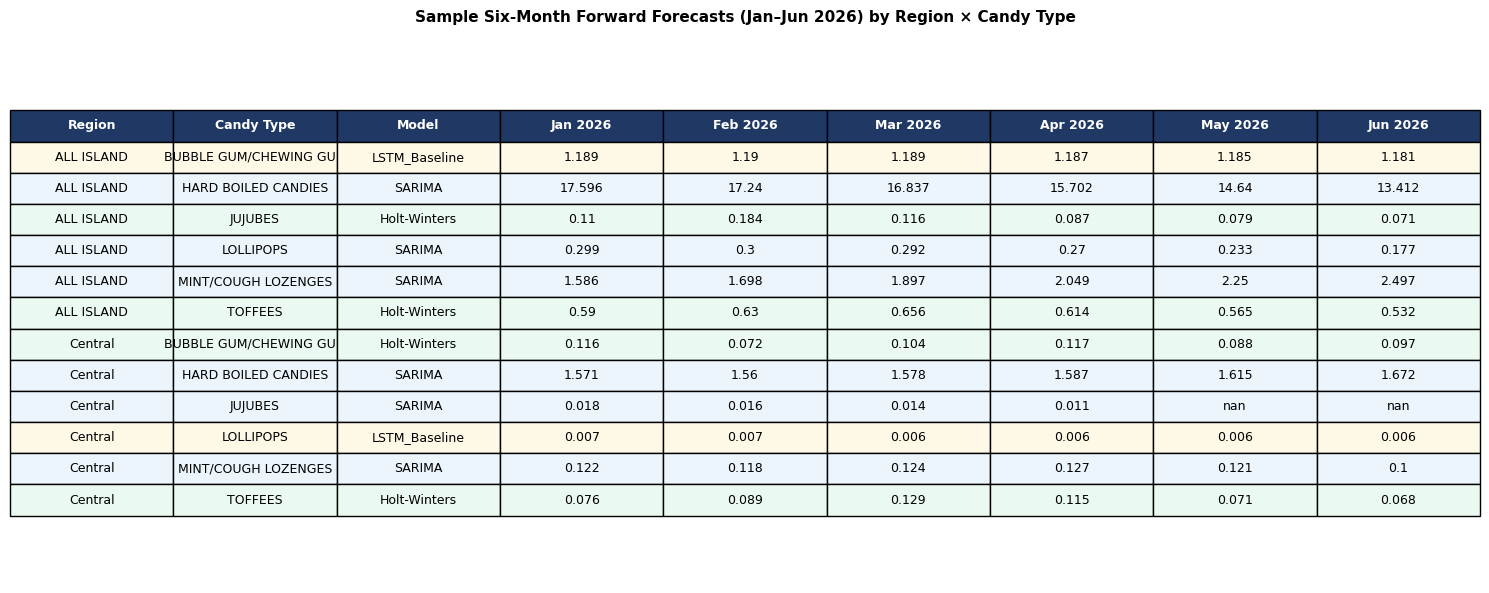


Total forecast rows in full output: 432
Total combinations: 72


In [43]:
# Table 5: Sample of six-month forward forecasts (Jan–Jun 2026)
sample = future_df.copy()
sample['Forecast'] = sample['Forecast'].round(3)
sample['Month']    = sample['Month'].dt.strftime('%b %Y')

# Pivot: rows = combination, columns = month
pivot_future = sample.pivot_table(
    index=['Region', 'Candy_Type', 'Model'],
    columns='Month',
    values='Forecast'
).reset_index()

# Reorder month columns chronologically
month_order = ['Jan 2026', 'Feb 2026', 'Mar 2026',
               'Apr 2026', 'May 2026', 'Jun 2026']
ordered_cols = ['Region', 'Candy_Type', 'Model'] + \
               [m for m in month_order if m in pivot_future.columns]
pivot_future = pivot_future[ordered_cols]

# Take top 12 rows
top12 = pivot_future.head(12)

fig, ax = plt.subplots(figsize=(15, 6))
ax.axis('off')

# Colour rows by model
row_colors = []
for model in top12['Model']:
    if model == 'SARIMA':
        row_colors.append(['#EBF5FB'] * len(ordered_cols))
    elif model == 'Holt-Winters':
        row_colors.append(['#EAFAF1'] * len(ordered_cols))
    else:
        row_colors.append(['#FEF9E7'] * len(ordered_cols))

# Column label display
col_display = ['Region', 'Candy Type', 'Model'] + \
              [m for m in month_order if m in pivot_future.columns]

table = ax.table(
    cellText=top12.values,
    colLabels=col_display,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Style header
for j in range(len(col_display)):
    table[0, j].set_facecolor('#1F3864')
    table[0, j].set_text_props(color='white', fontweight='bold')

fig.suptitle(
    'Sample Six-Month Forward Forecasts (Jan–Jun 2026) by Region × Candy Type',
    fontsize=11, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.savefig('table5_future_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal forecast rows in full output: {len(future_df)}')
print(f'Total combinations: {future_df.groupby(["Region","Candy_Type"]).ngroups}')

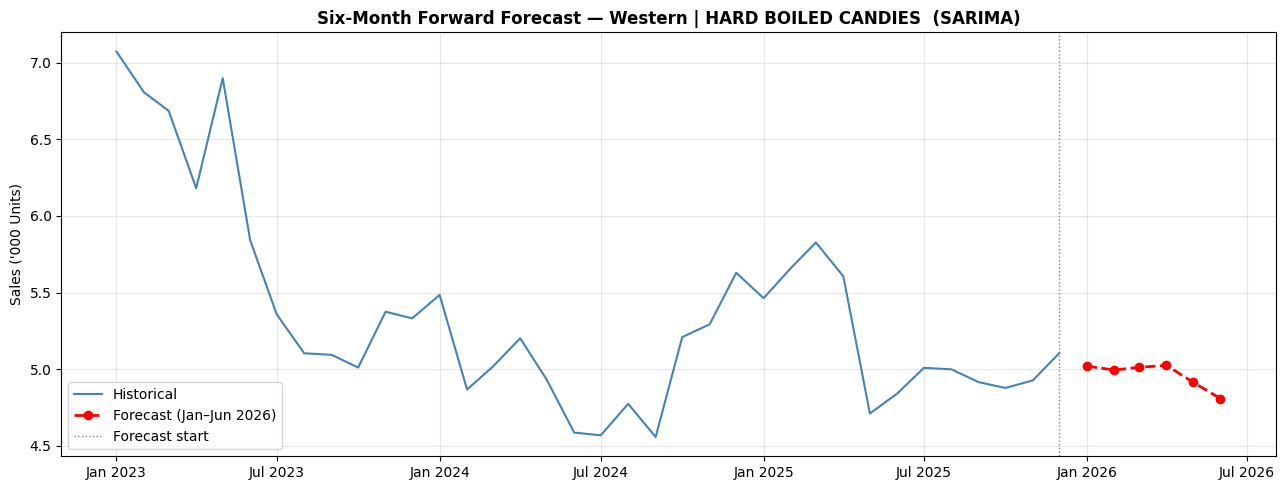

In [44]:
r, c = 'Western', 'HARD BOILED CANDIES'
series = get_series(r, c)

combo_fc = future_df[
    (future_df['Region'] == r) &
    (future_df['Candy_Type'] == c)
]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series.index, series.values,
        label='Historical', color='steelblue', linewidth=1.5)
ax.plot(combo_fc['Month'], combo_fc['Forecast'],
        label='Forecast (Jan–Jun 2026)', color='red',
        linestyle='--', linewidth=2, marker='o')
ax.axvline(series.index[-1], color='gray',
           linestyle=':', linewidth=1, label='Forecast start')
ax.set_title(f'Six-Month Forward Forecast — {r} | {c}  (SARIMA)',
             fontweight='bold', fontsize=12)
ax.set_ylabel("Sales ('000 Units)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure_future_forecast_western_hbc.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Exporting all results
sarima_df.to_csv('sarima_results.csv', index=False)
hw_df.to_csv('holtwinters_results.csv', index=False)
lstm_df.to_csv('lstm_results.csv', index=False)
all_trad.to_csv('all_model_results.csv', index=False)
best_per_combo.to_csv('best_model_per_combo.csv', index=False)
future_df.to_csv('future_forecasts_jan_jun_2026.csv', index=False)
print('All results exported:')
print(f'  SARIMA:       {len(sarima_df)} combos')
print(f'  Holt-Winters: {len(hw_df)} combos')
print(f'  LSTM:         {len(lstm_df)} combos')
print(f'  Best per combo: {len(best_per_combo)} combos')
print(f'  Future forecasts: {len(future_df)} rows')

All results exported:
  SARIMA:       72 combos
  Holt-Winters: 70 combos
  LSTM:         66 combos
  Best per combo: 72 combos
  Future forecasts: 432 rows


In [46]:
#Future work

In [47]:
#Prophet model

# Prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
np.random.seed(42)

PROPHET_GRID = {
    'changepoint_prior_scale': [0.1, 0.5, 1.0, 2.0],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative'],
    'changepoint_range':       [0.8, 0.9]
}
def prophet_cv_search(series, n_splits=3, verbose=False):
    """
    Grid search Prophet hyperparameters using manual TimeSeriesSplit CV.
    Each fold trains on growing history and tests on next 6 months.
    Returns: best_params dict, full results DataFrame.
    """
    n = len(series)
    initial_periods = max(18, n - n_splits * FORECAST_HORIZON)

    keys   = list(PROPHET_GRID.keys())
    values = list(PROPHET_GRID.values())
    param_combos = [dict(zip(keys, v)) for v in product(*values)]

    df_prop = series.reset_index()
    df_prop.columns = ['ds', 'y']
    df_prop['ds'] = pd.to_datetime(df_prop['ds'])

    results = []

    for params in param_combos:
        fold_mapes = []

        for fold in range(n_splits):
            cutoff_idx = initial_periods + fold * FORECAST_HORIZON
            if cutoff_idx + FORECAST_HORIZON > n:
                break

            train_df = df_prop.iloc[:cutoff_idx]
            test_df  = df_prop.iloc[cutoff_idx: cutoff_idx + FORECAST_HORIZON]

            try:
                m = Prophet(
                    changepoint_prior_scale=params['changepoint_prior_scale'],
                    seasonality_prior_scale=params['seasonality_prior_scale'],
                    seasonality_mode=params['seasonality_mode'],
                    changepoint_range=params['changepoint_range'],
                    yearly_seasonality=True,
                    weekly_seasonality=False,
                    daily_seasonality=False
                )
                m.fit(train_df)
                future = m.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
                fc     = m.predict(future)
                preds  = np.maximum(fc['yhat'].tail(FORECAST_HORIZON).values, 0)
                fold_mapes.append(mean_absolute_percentage_error(test_df['y'].values, preds))
            except:
                fold_mapes.append(np.inf)

        if fold_mapes:
            row = params.copy()
            row['CV_MAPE'] = round(np.mean(fold_mapes), 4)
            results.append(row)

    results_df = pd.DataFrame(results).sort_values('CV_MAPE').reset_index(drop=True)
    best_params = results_df.iloc[0].drop('CV_MAPE').to_dict()

    if verbose:
        print('Top 5 Prophet CV configs:')
        print(results_df.head())

    return best_params, results_df

In [48]:
def run_prophet(region, candy, horizon=FORECAST_HORIZON, verbose=False):
    series = get_series(region, candy)
    if len(series) < MIN_OBS:
        return None

    train, test = train_test_split_ts(series, horizon)

    #CV grid search on training data
    best_params, cv_df = prophet_cv_search(train, verbose=verbose)

    #Refit on full training set with best params
    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']
    df_train['ds'] = pd.to_datetime(df_train['ds'])

    final_model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode'],
        changepoint_range=float(best_params['changepoint_range']),
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    final_model.fit(df_train)

    future = final_model.make_future_dataframe(periods=horizon, freq='MS')
    fc     = final_model.predict(future)
    preds  = np.maximum(fc['yhat'].tail(horizon).values, 0)
    lower  = fc['yhat_lower'].tail(horizon).values
    upper  = fc['yhat_upper'].tail(horizon).values

    metrics = compute_metrics(test.values, preds, 'Prophet')
    metrics.update({
        'Region':      region,
        'Candy_Type':  candy,
        'Best_Params': str(best_params),
        'CV_MAPE':     round(cv_df.iloc[0]['CV_MAPE'], 4)
    })
    return metrics, preds, test, lower, upper, final_model, cv_df


NameError: name 'FORECAST_HORIZON' is not defined

In [ ]:
DEMO_R, DEMO_C = 'Western', 'TOFFEES'

print(f'Running Prophet CV search on {DEMO_R} – {DEMO_C} (64 combos × 3 folds)...')
result = run_prophet(DEMO_R, DEMO_C, verbose=True)

if result:
    metrics, preds, test, lower, upper, model, cv_df = result

    print('\nBest params:', metrics['Best_Params'])
    print('Test MAPE:  ', metrics['MAPE'])
    print('CV MAPE:    ', metrics['CV_MAPE'])
    print('RMSE:       ', metrics['RMSE'])
    print('MAE:        ', metrics['MAE'])

    #CV MAPE heatmap
    best_mode = eval(metrics['Best_Params'])['seasonality_mode']
    pivot_data = cv_df[cv_df['seasonality_mode'] == best_mode].groupby(
        ['changepoint_prior_scale', 'seasonality_prior_scale']
    )['CV_MAPE'].min().reset_index()
    pivot = pivot_data.pivot(
        index='changepoint_prior_scale',
        columns='seasonality_prior_scale',
        values='CV_MAPE'
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
                cbar_kws={'label': 'CV MAPE'})
    ax.set_title(f'Prophet CV MAPE Heatmap — {DEMO_R} | {DEMO_C}\nmode={best_mode}')
    ax.set_xlabel('seasonality_prior_scale')
    ax.set_ylabel('changepoint_prior_scale')
    plt.tight_layout()
    plt.show()

    #Forecast plot
    series = get_series(DEMO_R, DEMO_C)
    train, _ = train_test_split_ts(series)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train.index, train.values, label='Train', color='steelblue')
    ax.plot(test.index, test.values, label='Actual', color='green', linewidth=2)
    ax.plot(test.index, preds, label='Prophet (CV-tuned)', color='purple',
            linestyle='--', linewidth=2)
    ax.fill_between(test.index, lower, upper,
                    alpha=0.12, color='purple', label='Uncertainty interval')
    ax.set_title(
        f'Prophet — {DEMO_R} | {DEMO_C}\n'
        f'MAPE={metrics["MAPE"]:.2%}   CV_MAPE={metrics["CV_MAPE"]:.2%}'
    )
    ax.set_ylabel("Sales ('000 Units)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    #Component plots (trend + yearly seasonality)
    future_all = model.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    fc_all = model.predict(future_all)
    model.plot_components(fc_all)
    plt.tight_layout()
    plt.show()

In [ ]:
prophet_results = []

for r, c in combos:
    try:
        res = run_prophet(r, c)
        if res:
            prophet_results.append(res[0])
            print(f' {r} – {c}  MAPE={res[0]["MAPE"]:.2%}')
    except Exception as e:
        print(f'  Skipped {r} – {c}: {e}')

prophet_df = pd.DataFrame(prophet_results)
prophet_df.to_csv('prophet_results.csv', index=False)

print(f'\n Prophet done: {len(prophet_df)} combos')
print(prophet_df[['Region','Candy_Type','MAPE','RMSE','MAE','CV_MAPE']].sort_values('MAPE').head(10))